In [ ]:
# 10 — Does the Effect Vary by Context?

The main research question asks not only how direction affects outcomes, but
how that relationship VARIES with rally phase, surface, gender and pressure.
Section 7 answered the first half using one global estimate. This notebook
answers the second half by repeating the counterfactual within each segment.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.sparse as sp
import pickle
from pathlib import Path

from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import f1_score, accuracy_score
from xgboost import XGBClassifier

sns.set_style("whitegrid")

CWD = Path.cwd()
PROJECT_ROOT = CWD if (CWD / "data").exists() else CWD.parent
PROCESSED = PROJECT_ROOT / "data" / "processed"
FIGURES = PROJECT_ROOT / "figures"

data = pd.read_parquet(PROCESSED / "model_data.parquet")

CATEGORICAL = ["shot_type", "direction", "direction_pattern", "to_opponent_wing",
               "prev_shot_type", "prev_direction", "prev_depth",
               "serve_direction", "pressure_context", "Surface", "gender"]
NUMERIC = ["shot_number", "is_approach", "prev_approach",
           "is_serving", "is_second_serve"]

for col in CATEGORICAL:
    data[col] = data[col].fillna("none").astype(str)
for col in NUMERIC:
    data[col] = data[col].fillna(0).astype(float)

CLASSES = ["in_play", "unforced_error", "forced_error", "winner"]
label_to_int = {name: i for i, name in enumerate(CLASSES)}

print("Data:", data.shape)

Data: (5207197, 21)


In [3]:
# Reload the unweighted probability model used for counterfactuals.
with open(PROCESSED / "model_artifacts.pkl", "rb") as f:
    artifacts = pickle.load(f)

cf_encoder = artifacts["encoder"]
cf_model = artifacts["xgb"]

PATTERNS = ["cross_court", "down_the_line", "middle"]


def counterfactual_net_value(subset):
    """
    Re-score the same shots under each direction, changing nothing else.
    Returns the net value (winner + forced error - unforced error) per pattern.
    """
    results = {}
    for pattern in PATTERNS:
        scenario = subset.copy()
        scenario["direction_pattern"] = pattern

        matrix = sp.hstack([cf_encoder.transform(scenario[CATEGORICAL]),
                            sp.csr_matrix(scenario[NUMERIC].values)]).tocsr()
        probabilities = cf_model.predict_proba(matrix).mean(axis=0)

        results[pattern] = (probabilities[CLASSES.index("winner")]
                            + probabilities[CLASSES.index("forced_error")]
                            - probabilities[CLASSES.index("unforced_error")])
    return results


# Only rally shots can have a direction pattern.
rally_shots = data[data["direction_pattern"] != "none"]
print("Rally shots available:", len(rally_shots))

Rally shots available: 4012042


In [4]:
# Rally length was excluded from the FEATURES list because it leaks the
# outcome. It is used here only to SPLIT the data into segments, never as a
# model input, so no leakage is introduced.
points = pd.read_parquet(PROCESSED / "points_eda.parquet")
rally_shots = rally_shots.merge(
    points[["match_id", "Pt", "rally_length"]], on=["match_id", "Pt"], how="left")

rally_shots["rally_phase"] = pd.cut(rally_shots["rally_length"],
                                    bins=[0, 4, 8, np.inf],
                                    labels=["short (1-4)", "medium (5-8)", "long (9+)"])
print(rally_shots["rally_phase"].value_counts())

rally_phase
long (9+)       1980770
medium (5-8)    1511012
short (1-4)      535564
Name: count, dtype: int64


In [5]:
# Each segment is re-scored independently, so the comparison inside a segment
# is always like-for-like.
SEGMENTS = {
    "Surface": ["Hard", "Clay", "Grass"],
    "gender": ["M", "W"],
    "rally_phase": ["short (1-4)", "medium (5-8)", "long (9+)"],
    "pressure_context": ["regular", "game_point", "break_point", "deuce", "tiebreak"],
}

MIN_SHOTS = 5000
MAX_SHOTS = 50_000

rows = []
for variable, levels in SEGMENTS.items():
    for level in levels:
        subset = rally_shots[rally_shots[variable].astype(str) == str(level)]
        if len(subset) < MIN_SHOTS:
            print(f"Skipping {variable}={level}: only {len(subset)} shots")
            continue
        if len(subset) > MAX_SHOTS:
            subset = subset.sample(MAX_SHOTS, random_state=42)

        values = counterfactual_net_value(subset)
        rows.append({
            "variable": variable,
            "segment": str(level),
            "n_shots": len(subset),
            "cross_court": values["cross_court"],
            "down_the_line": values["down_the_line"],
            "middle": values["middle"],
            "dtl_minus_cc": values["down_the_line"] - values["cross_court"],
        })

segmented = pd.DataFrame(rows)
print(segmented.round(4).to_string(index=False))

        variable      segment  n_shots  cross_court  down_the_line  middle  dtl_minus_cc
         Surface         Hard    50000       0.0199         0.0266  0.0277        0.0067
         Surface         Clay    50000       0.0170         0.0217  0.0242        0.0047
         Surface        Grass    50000       0.0415         0.0536  0.0496        0.0121
          gender            M    50000       0.0257         0.0288  0.0316        0.0031
          gender            W    50000       0.0145         0.0272  0.0254        0.0127
     rally_phase  short (1-4)    50000       0.0500         0.0720  0.0615        0.0220
     rally_phase medium (5-8)    50000       0.0401         0.0506  0.0475        0.0106
     rally_phase    long (9+)    50000       0.0001        -0.0008  0.0065       -0.0009
pressure_context      regular    50000       0.0204         0.0269  0.0281        0.0065
pressure_context   game_point    50000       0.0275         0.0379  0.0370        0.0104
pressure_context  bre

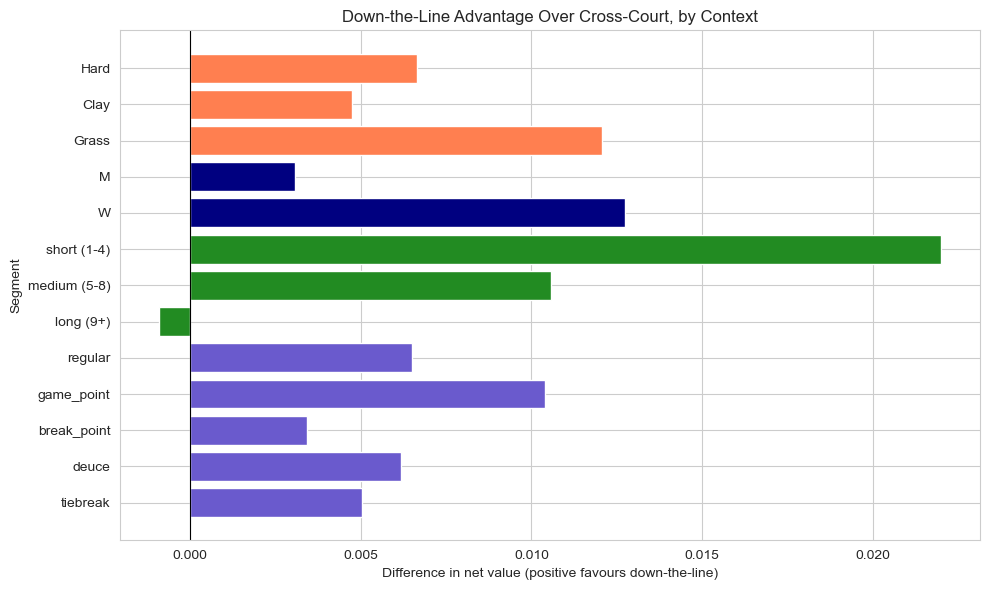

In [6]:
# If the bars are all similar, the risk-reward relationship is stable across
# contexts. If they differ, context changes how valuable direction choice is.
plt.figure(figsize=(10, 6))
colours = {"Surface": "coral", "gender": "navy",
           "rally_phase": "forestgreen", "pressure_context": "slateblue"}
bar_colours = [colours[v] for v in segmented["variable"]]

plt.barh(segmented["segment"][::-1], segmented["dtl_minus_cc"][::-1],
         color=bar_colours[::-1])
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Down-the-Line Advantage Over Cross-Court, by Context")
plt.xlabel("Difference in net value (positive favours down-the-line)")
plt.ylabel("Segment")
plt.tight_layout()
plt.savefig(FIGURES / "segmented_direction_effect.png", dpi=150)
plt.show()

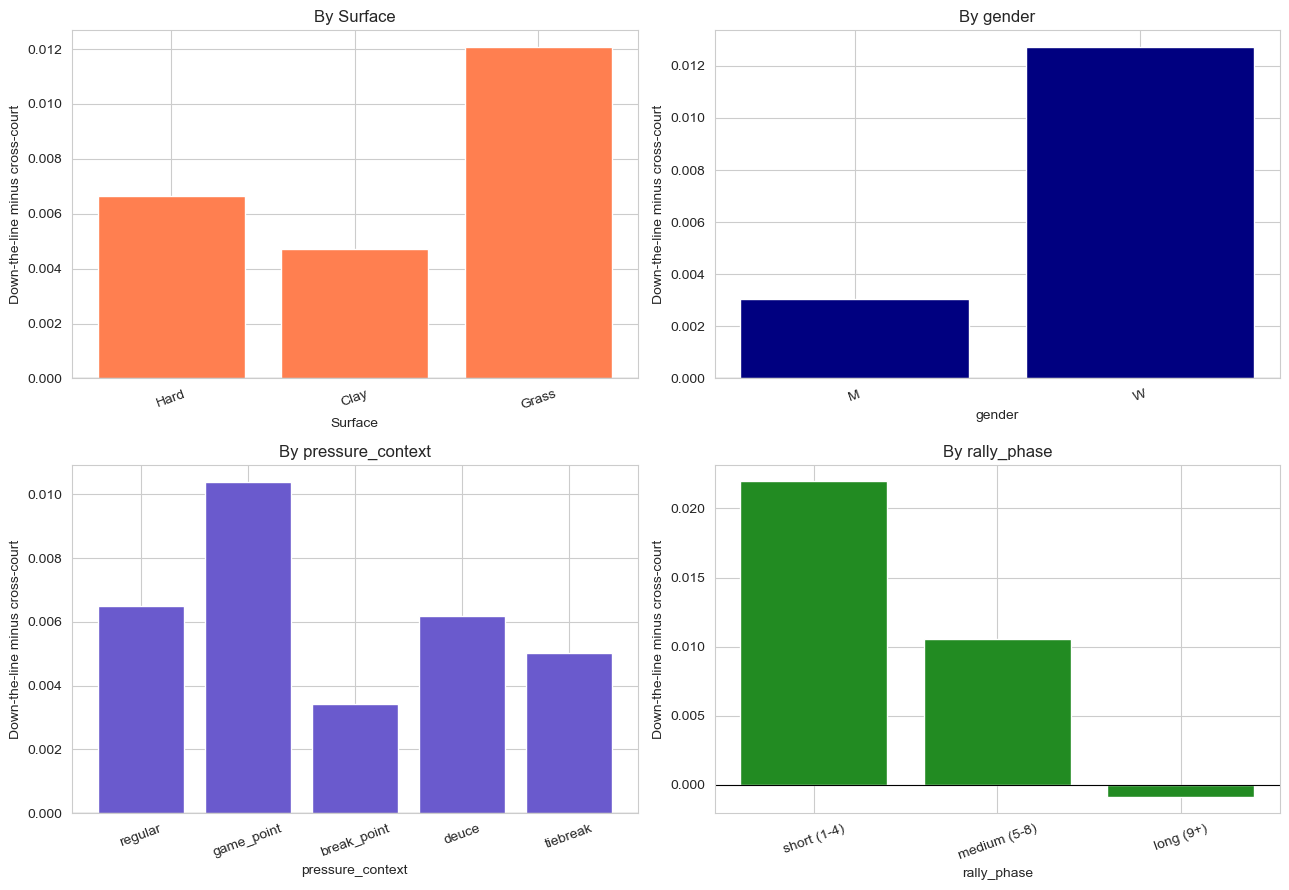

In [7]:
# Same numbers grouped by variable, which makes within-variable comparison
# easier than the single ranked chart above.
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

for ax, (variable, group) in zip(axes.flat, segmented.groupby("variable")):
    ax.bar(group["segment"], group["dtl_minus_cc"], color=colours[variable])
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_title(f"By {variable}")
    ax.set_xlabel(variable)
    ax.set_ylabel("Down-the-line minus cross-court")
    ax.tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.savefig(FIGURES / "segmented_direction_by_variable.png", dpi=150)
plt.show()

segmented.to_csv(FIGURES / "segmented_effects.csv", index=False)

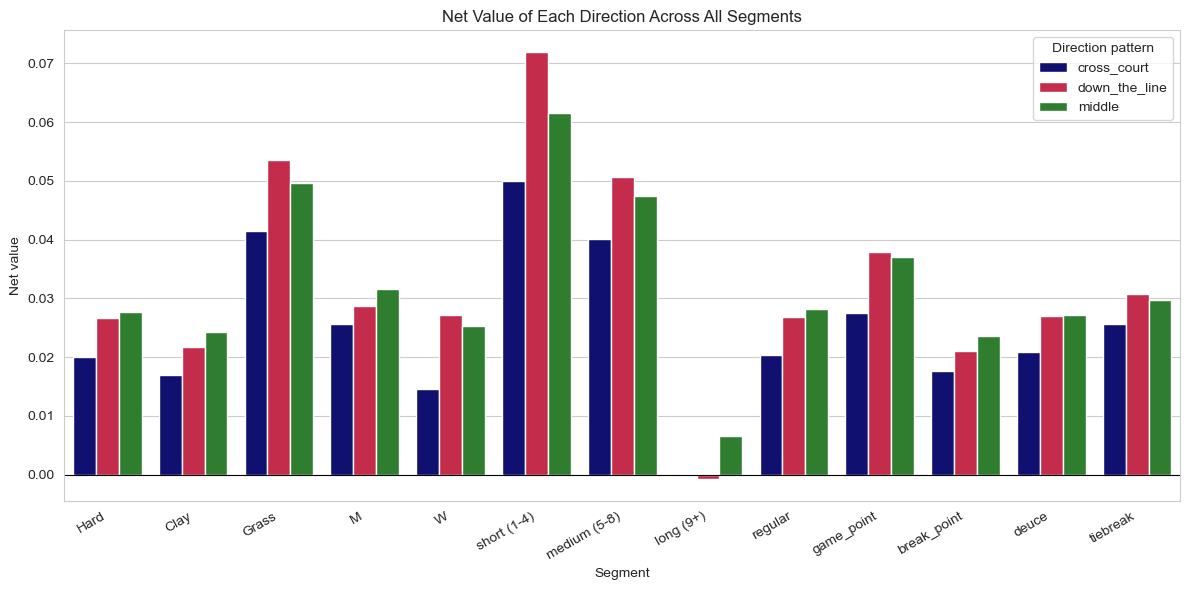

In [8]:
# The full picture: not just the gap, but the level of each option.
melted = segmented.melt(id_vars=["variable", "segment"],
                        value_vars=PATTERNS,
                        var_name="pattern", value_name="net_value")

plt.figure(figsize=(12, 6))
sns.barplot(data=melted, x="segment", y="net_value", hue="pattern",
            palette=["navy", "crimson", "forestgreen"])
plt.axhline(0, color="black", linewidth=0.8)
plt.title("Net Value of Each Direction Across All Segments")
plt.xlabel("Segment")
plt.ylabel("Net value")
plt.xticks(rotation=30, ha="right")
plt.legend(title="Direction pattern")
plt.tight_layout()
plt.savefig(FIGURES / "segmented_all_patterns.png", dpi=150)
plt.show()